In [16]:
import os
import glob
import numpy as np
import pandas as pd
from scipy.stats import kurtosis, skew
from scipy.fft import rfft
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Define your exact Windows path
data_folder = r"C:\Users\risik\OneDrive\Desktop\Predictive Maintenance for Industrial Bearings\2nd_test"

# 2. Extract features from each timestamped text file
def process_nasa_ims_folder(folder_path):
    # Sort files chronologically by filename
    file_list = sorted(glob.glob(os.path.join(folder_path, "*")))
    print(f"Total snapshot files detected: {len(file_list)}")
    
    records = []
    for i, file_path in enumerate(file_list):
        try:
            # Files are tab-separated; column 0 corresponds to Bearing 1
            df_snapshot = pd.read_csv(file_path, sep=r'\s+', header=None)
            b1_signal = df_snapshot[0].values
            
            # Time-domain metrics
            rms = np.sqrt(np.mean(b1_signal**2))
            kurt = kurtosis(b1_signal)
            ptp = np.ptp(b1_signal)
            crest = np.max(np.abs(b1_signal)) / (rms + 1e-8)
            skw = skew(b1_signal)
            
            # Frequency-domain (FFT) peak
            n = len(b1_signal)
            fft_vals = np.abs(rfft(b1_signal)) * (2.0 / n)
            max_fft_peak = np.max(fft_vals)
            
            records.append({
                "Filename": os.path.basename(file_path),
                "RMS": rms,
                "Kurtosis": kurt,
                "Peak_to_Peak": ptp,
                "Crest_Factor": crest,
                "Skewness": skw,
                "Max_FFT_Peak": max_fft_peak
            })
            
            if (i + 1) % 100 == 0 or (i + 1) == len(file_list):
                print(f"Processed {i + 1}/{len(file_list)} files...")
                
        except Exception as e:
            print(f"Skipping {os.path.basename(file_path)} due to error: {e}")
            continue
            
    df_nasa = pd.DataFrame(records)
    
    # Calculate RUL (Remaining cycles to failure)
    df_nasa["Cycle"] = df_nasa.index
    df_nasa["RUL_Cycles"] = len(df_nasa) - df_nasa.index - 1
    
    # Label Health States based on degradation profile
    # IMS Set 2 has 984 total cycles: Normal (~0-530), Early Warning (~530-700), Critical/Failure (>700)
  # Define cycle boundaries and category labels
    bins = [-1, 529, 699, len(df_nasa)]
    labels = ["Normal", "Early_Degradation", "Severe_Fault"]
    
    df_nasa["Health_State"] = pd.cut(df_nasa["Cycle"], bins=bins, labels=labels)
    return df_nasa

# Run the parser
df_nasa = process_nasa_ims_folder(data_folder)
print("\nSample Feature Extraction:")
print(df_nasa.head())

Total snapshot files detected: 984
Processed 100/984 files...
Processed 200/984 files...
Processed 300/984 files...
Processed 400/984 files...
Processed 500/984 files...
Processed 600/984 files...
Processed 700/984 files...
Processed 800/984 files...
Processed 900/984 files...
Processed 984/984 files...

Sample Feature Extraction:
              Filename       RMS  Kurtosis  Peak_to_Peak  Crest_Factor  \
0  2004.02.12.10.32.39  0.074179  0.628763         0.840      6.120330   
1  2004.02.12.10.42.39  0.075382  0.648291         0.757      5.147085   
2  2004.02.12.10.52.39  0.076230  0.513475         0.903      6.598471   
3  2004.02.12.11.02.39  0.078724  1.157953         1.184      7.723216   
4  2004.02.12.11.12.39  0.078474  0.603177         0.782      4.982523   

   Skewness  Max_FFT_Peak  Cycle  RUL_Cycles Health_State  
0  0.083993      0.042302      0         983       Normal  
1  0.052142      0.035461      1         982       Normal  
2  0.032808      0.033781      2         9

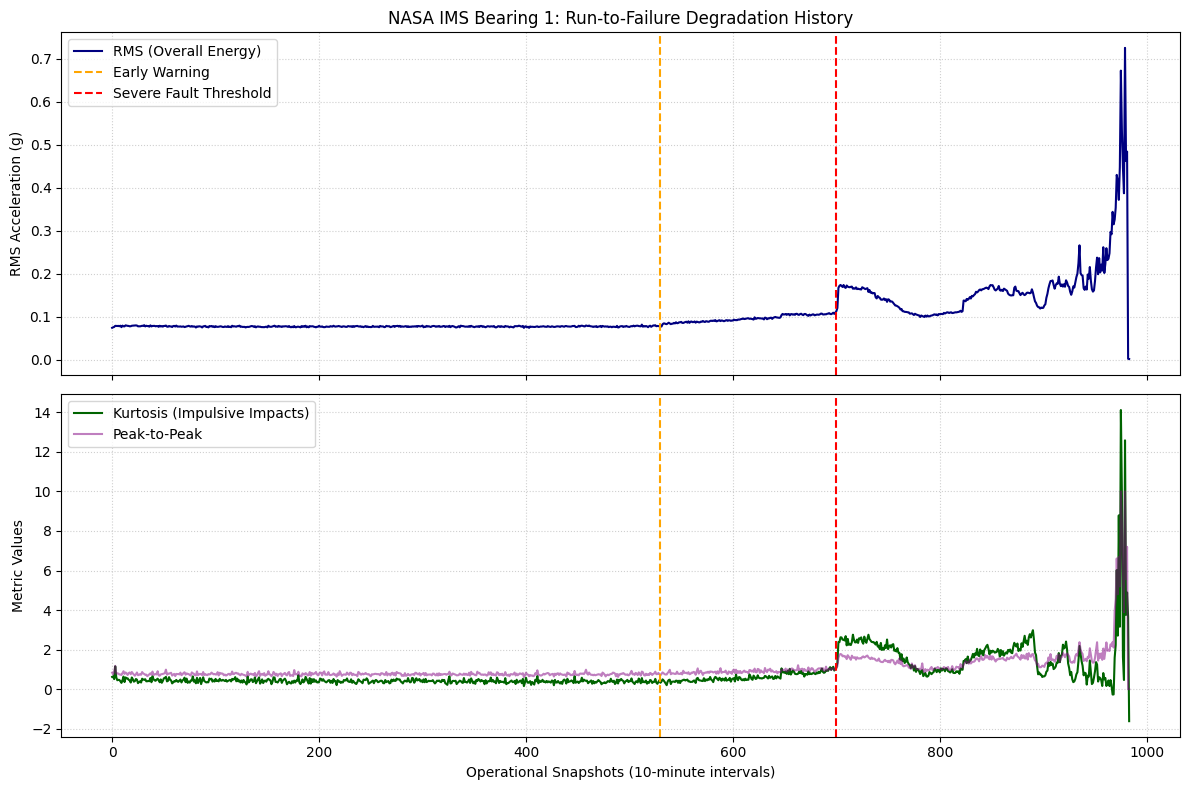

In [17]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# RMS Trend
ax1.plot(df_nasa["Cycle"], df_nasa["RMS"], color="navy", label="RMS (Overall Energy)")
ax1.axvline(x=530, color="orange", linestyle="--", label="Early Warning")
ax1.axvline(x=700, color="red", linestyle="--", label="Severe Fault Threshold")
ax1.set_ylabel("RMS Acceleration (g)")
ax1.set_title("NASA IMS Bearing 1: Run-to-Failure Degradation History")
ax1.grid(True, linestyle=":", alpha=0.6)
ax1.legend()

# Kurtosis & Peak-to-Peak Trend
ax2.plot(df_nasa["Cycle"], df_nasa["Kurtosis"], color="darkgreen", label="Kurtosis (Impulsive Impacts)")
ax2.plot(df_nasa["Cycle"], df_nasa["Peak_to_Peak"], color="purple", alpha=0.5, label="Peak-to-Peak")
ax2.axvline(x=530, color="orange", linestyle="--")
ax2.axvline(x=700, color="red", linestyle="--")
ax2.set_xlabel("Operational Snapshots (10-minute intervals)")
ax2.set_ylabel("Metric Values")
ax2.grid(True, linestyle=":", alpha=0.6)
ax2.legend()

plt.tight_layout()
plt.show()

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import classification_report, confusion_matrix, mean_squared_error, r2_score

# Feature set
features = ["RMS", "Kurtosis", "Peak_to_Peak", "Crest_Factor", "Skewness", "Max_FFT_Peak"]
X = df_nasa[features]
y_class = df_nasa["Health_State"]
y_reg = df_nasa["RUL_Cycles"]

# Train/Test Split
X_train, X_test, y_class_train, y_class_test, y_reg_train, y_reg_test = train_test_split(
    X, y_class, y_reg, test_size=0.25, random_state=42
)

# 1. Classification Model
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_class_train)
y_pred_class = clf.predict(X_test)

print("=== Health Stage Classification Report ===")
print(classification_report(y_class_test, y_pred_class))

# 2. RUL Regression Model
reg = RandomForestRegressor(n_estimators=100, random_state=42)
reg.fit(X_train, y_reg_train)
y_pred_reg = reg.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_reg_test, y_pred_reg))
r2 = r2_score(y_reg_test, y_pred_reg)
print(f"=== RUL Regression Results ===")
print(f"Root Mean Squared Error: {rmse:.2f} cycles")
print(f"R² Score: {r2:.4f}")

=== Health Stage Classification Report ===
                   precision    recall  f1-score   support

Early_Degradation       0.98      0.96      0.97        49
           Normal       1.00      1.00      1.00       137
     Severe_Fault       0.97      0.98      0.98        60

         accuracy                           0.99       246
        macro avg       0.98      0.98      0.98       246
     weighted avg       0.99      0.99      0.99       246

=== RUL Regression Results ===
Root Mean Squared Error: 118.26 cycles
R² Score: 0.8113


=== Health Stage Classification Report ===
                   precision    recall  f1-score   support

Early_Degradation       0.98      0.96      0.97        49
           Normal       1.00      1.00      1.00       137
     Severe_Fault       0.97      0.98      0.98        60

         accuracy                           0.99       246
        macro avg       0.98      0.98      0.98       246
     weighted avg       0.99      0.99      0.99       246

=== RUL Regression Results ===
Root Mean Squared Error: 118.26 cycles (1182.6 operational minutes)
R² Score: 0.8113


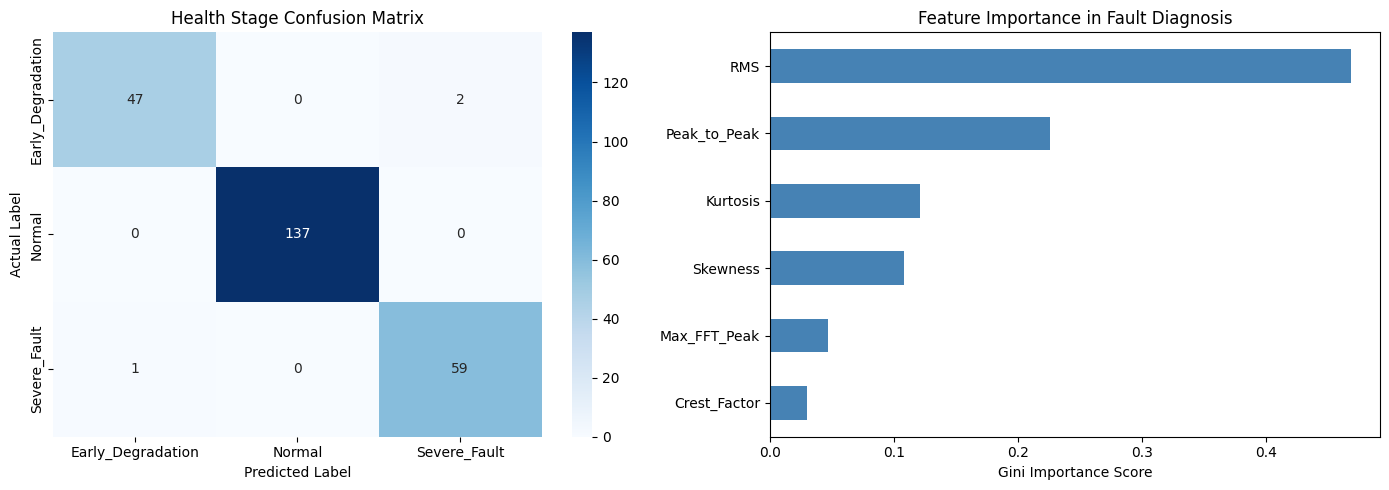


Feature dataset successfully saved to: C:\Users\risik\OneDrive\Desktop\Predictive Maintenance for Industrial Bearings\ims_bearing_features.csv


In [19]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import classification_report, confusion_matrix, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Prepare Feature Matrix and Target Variables
features = ["RMS", "Kurtosis", "Peak_to_Peak", "Crest_Factor", "Skewness", "Max_FFT_Peak"]
X = df_nasa[features]
y_class = df_nasa["Health_State"]
y_reg = df_nasa["RUL_Cycles"]

# 2. Train/Test Split (75% Train, 25% Test)
X_train, X_test, y_class_train, y_class_test, y_reg_train, y_reg_test = train_test_split(
    X, y_class, y_reg, test_size=0.25, random_state=42
)

# 3. Model 1: Fault Stage Classifier
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_class_train)
y_pred_class = clf.predict(X_test)

print("=== Health Stage Classification Report ===")
print(classification_report(y_class_test, y_pred_class))

# 4. Model 2: RUL (Remaining Useful Life) Regressor
reg = RandomForestRegressor(n_estimators=100, random_state=42)
reg.fit(X_train, y_reg_train)
y_pred_reg = reg.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_reg_test, y_pred_reg))
r2 = r2_score(y_reg_test, y_pred_reg)
print(f"=== RUL Regression Results ===")
print(f"Root Mean Squared Error: {rmse:.2f} cycles ({rmse*10:.1f} operational minutes)")
print(f"R² Score: {r2:.4f}")

# 5. Visual Diagnostics: Confusion Matrix & Feature Importance
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix
cm = confusion_matrix(y_class_test, y_pred_class, labels=clf.classes_)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", 
            xticklabels=clf.classes_, yticklabels=clf.classes_, ax=axes[0])
axes[0].set_title("Health Stage Confusion Matrix")
axes[0].set_xlabel("Predicted Label")
axes[0].set_ylabel("Actual Label")

# Feature Importance
importance = pd.Series(clf.feature_importances_, index=features).sort_values(ascending=True)
importance.plot(kind="barh", color="steelblue", ax=axes[1])
axes[1].set_title("Feature Importance in Fault Diagnosis")
axes[1].set_xlabel("Gini Importance Score")

plt.tight_layout()
plt.show()

# 6. Save Processed Features to CSV
output_csv = r"C:\Users\risik\OneDrive\Desktop\Predictive Maintenance for Industrial Bearings\ims_bearing_features.csv"
df_nasa.to_csv(output_csv, index=False)
print(f"\nFeature dataset successfully saved to: {output_csv}")